In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

### Численно взятая производная

In [2]:
def f(x):
    return math.sin(x)

def d1_num(x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

def d2_num(x, h):
    return (f(x + h) - 2 * f(x) + f(x - h)) / h ** 2

x, h = 5, 0.001
print(f"f(5) = {f(x)}")
print(f"f'(5) = {d1_num(x, h)}")
print(f"f''(5) = {d2_num(x, h)}")


f(5) = -0.9589242746631385
f'(5) = 0.2836621381863136
f''(5) = 0.9589241947161042


### Аналитически взятая производная

In [3]:
def d1_analit(x):
    return math.cos(x)

def d2_analit(x):
    return - math.sin(x)

x = 5
print(f"f(5) = {f(x)}")
print(f"f'(5) = {d1_analit(x)}")
print(f"f''(5) = {d2_analit(x)}")

f(5) = -0.9589242746631385
f'(5) = 0.28366218546322625
f''(5) = 0.9589242746631385


### Сравнение: численно против аналитически

Наложить кривые друг на друга здесь нельзя: при h = 0.001 разница между численной и аналитической производной порядка 10⁻⁷ при амплитуде кривой 1 — на обычном графике они совпадут до толщины линии. Поэтому сравниваем не кривые, а их разность.

- **График Б** — разность по x при нескольких h (лог. шкала по y): ошибка падает как h², и у каждой производной есть точки, где она проваливается к машинному нулю (обнуляется f‴ для f′ и f⁗ для f″).
- **График В** — та же разность в одной точке x₀, по h от 10⁻¹ до 10⁻¹³ (обе оси лог.): галка. Слева ошибка метода — падает как h²; справа ошибка округления — растёт как 1/h (f′) и 1/h² (f″). Дно — это предел, который ставит не метод, а точность чисел в машине.

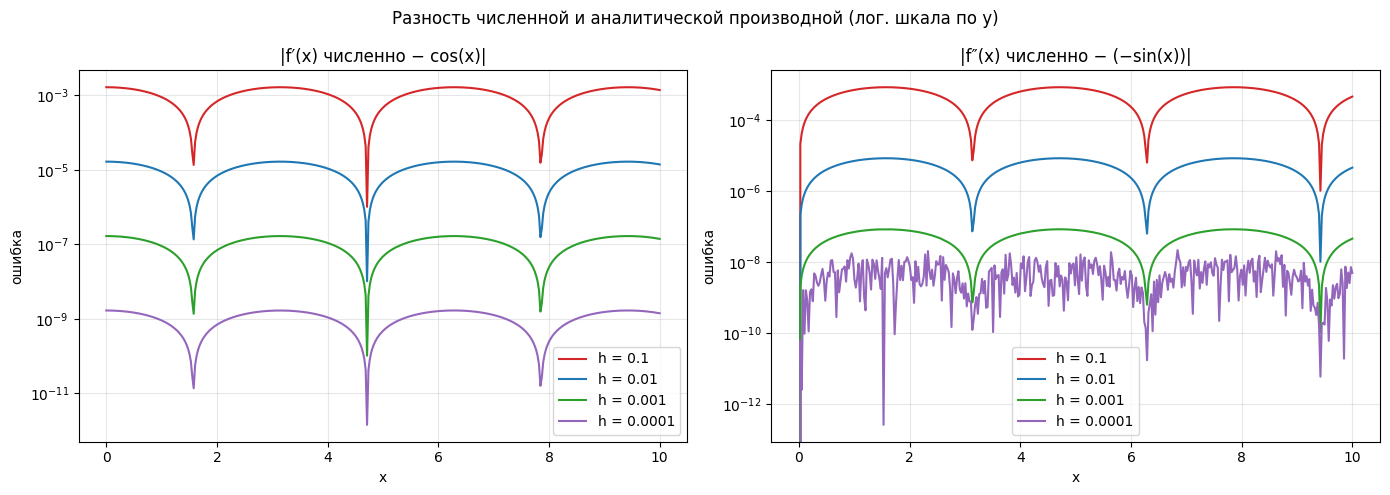

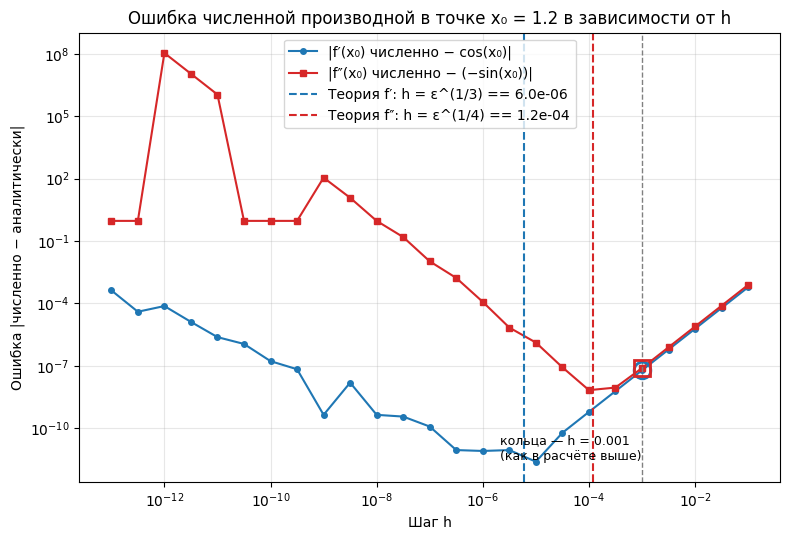

f′: минимальная ошибка 2.43e-12 достигается при h ≈ 1.0e-05 (теория: 6.0e-06)
f″: минимальная ошибка 6.72e-09 достигается при h ≈ 1.0e-04 (теория: 1.2e-04)
при h = 0.001: ошибка f′ = 6.04e-08, ошибка f″ = 7.78e-08


In [9]:
# ============================================================
# Вариант Б: разность |численно − аналитически| по x
# ============================================================
xs = np.linspace(0, 10, 400)
h_list = [0.1, 0.01, 0.001, 0.0001]
colors = ["#d62728", "#1f77b4", "#2ca02c", "#9467bd"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for h, color in zip(h_list, colors):
    err1 = [abs(d1_num(x, h) - d1_analit(x)) for x in xs]
    err2 = [abs(d2_num(x, h) - d2_analit(x)) for x in xs]
    axes[0].semilogy(xs, err1, color=color, label=f"h = {h}")
    axes[1].semilogy(xs, err2, color=color, label=f"h = {h}")

axes[0].set_title("|f′(x) численно − cos(x)|")
axes[1].set_title("|f″(x) численно − (−sin(x))|")
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("ошибка")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

fig.suptitle("Разность численной и аналитической производной (лог. шкала по y)", fontsize=12)
plt.tight_layout()
plt.show()

# ============================================================
# Вариант В: «галка» — ошибка в точке x0 в зависимости от h
# ============================================================
x0 = 1.2
hs = np.logspace(-1, -13, 25)

e1 = [abs(d1_num(x0, h) - d1_analit(x0)) for h in hs]
e2 = [abs(d2_num(x0, h) - d2_analit(x0)) for h in hs]

plt.figure(figsize=(8, 5.5))
plt.loglog(hs, e1, "o-", color="#1f77b4", ms=4, label="|f′(x₀) численно − cos(x₀)|")
plt.loglog(hs, e2, "s-", color="#d62728", ms=4, label="|f″(x₀) численно − (−sin(x₀))|")

# отмечаем h = 0.001 — то, которым считали в ячейках выше
e1_1e3 = abs(d1_num(x0, 1e-3) - d1_analit(x0))
e2_1e3 = abs(d2_num(x0, 1e-3) - d2_analit(x0))
plt.axvline(1e-3, color="gray", linestyle="--", linewidth=1)
plt.plot(1e-3, e1_1e3, "o", color="#1f77b4", ms=12, mfc="none", mew=2)
plt.plot(1e-3, e2_1e3, "s", color="#d62728", ms=12, mfc="none", mew=2)
plt.text(0.60, 0.05, "кольца — h = 0.001\n(как в расчёте выше)",
         transform=plt.gca().transAxes, fontsize=9)

#Теоретические оптимумы (машинный eps == 2.2e-16)
eps = 2.2e-16
h_opt1 = eps ** (1/3)  # Оптимум для первой производной
h_opt2 = eps ** (1/4)  # Оптимум для второй производной 
plt.axvline(h_opt1, color="#1f77b4", linestyle="--", linewidth=1.5,
            label=f"Теория f′: h = ε^(1/3) == {h_opt1:.1e}")
plt.axvline(h_opt2, color="#d62728", linestyle="--", linewidth=1.5,
            label=f"Теория f″: h = ε^(1/4) == {h_opt2:.1e}")

plt.xlabel("Шаг h")
plt.ylabel("Ошибка |численно − аналитически|")
plt.title(f"Ошибка численной производной в точке x₀ = {x0} в зависимости от h")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Дно галки — числом, а не только глазами
i1 = int(np.argmin(e1))
i2 = int(np.argmin(e2))
print(f"f′: минимальная ошибка {e1[i1]:.2e} достигается при h ≈ {hs[i1]:.1e} (теория: {h_opt1:.1e})")
print(f"f″: минимальная ошибка {e2[i2]:.2e} достигается при h ≈ {hs[i2]:.1e} (теория: {h_opt2:.1e})")
print(f"при h = 0.001: ошибка f′ = {e1_1e3:.2e}, ошибка f″ = {e2_1e3:.2e}")


### График своими руками

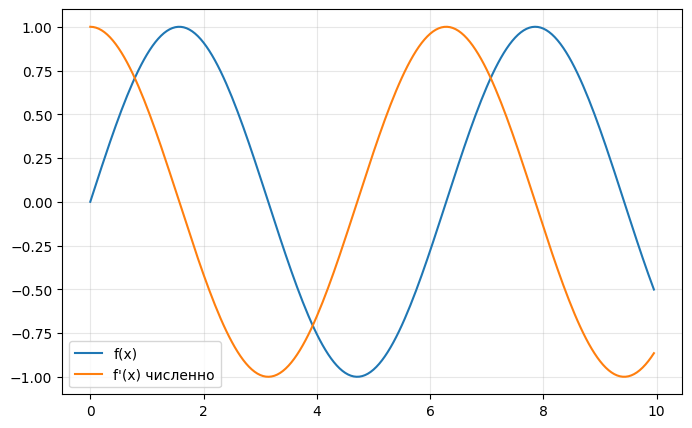

In [5]:

xs = [i * 0.05 for i in range(0, 200)]

# Вычисляем значения функции и её численной производной для каждой точки
ys = [f(x) for x in xs]
dys = [d1_num(x, 0.001) for x in xs]

# Строим график на одних осях
plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label="f(x)")
plt.plot(xs, dys, label="f'(x) численно")
# Оформление
plt.legend()
plt.grid(alpha=0.3)
plt.show()
